In [6]:
# !pip install mediapipe-silicon opencv-python pandas scikit-learn

## 1. Import Dependencies

In [21]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_holistic = mp.solutions.holistic
mp_pose = mp.solutions.pose

## 2. Capture Landmarks and Export CSV

#### 2_1. Import Dependencies

In [22]:
import csv
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Define column names: frame_no, rep_id, followed by x, y, z, v for 33 landmarks
landmarks = ['frame_no', 'rep_id']
for val in range(1, 33+1):
    landmarks += [f'x{val}', f'y{val}', f'z{val}', f'v{val}']

csv_filename = 'hip_abduction_coords.csv'


# Initialize the CSV file with headers
with open(csv_filename, mode='w', newline='') as f:
    csv_writer = csv.writer(f, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
    csv_writer.writerow(landmarks)

print(f"Successfully created {csv_filename} with headers.")

Successfully created hip_abduction_coords.csv with headers.
Successfully created 2nd hip_abduction_coords_normalized.csv with headers.


In [27]:
def export_landmark(results, frame_num, rep_id):
    try:
        # Extract Pose landmarks
        pose_landmarks = results.pose_landmarks.landmark
        
        # Create row: [Frame No, Rep ID, x1, y1, z1, v1, x2...]
        row = [frame_num, rep_id] + [coord for res in pose_landmarks for coord in [res.x, res.y, res.z, res.visibility]]
        
        # Append to CSV
        with open(csv_filename, mode='a', newline='') as f:
            csv_writer = csv.writer(f, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
            csv_writer.writerow(row)
            
    except Exception as e:
        print(f"Error saving frame: {e}")

In [29]:
rep_counter = 1     # Starts at Rep 1

### Hip Abduction

In [ ]:

# Path to your video file
video_path = r'C:\Users\Mukaram Awan\Downloads\Dataset for AutoEncoder\Dataset\26\10\cam1.mp4'
cap = cv2.VideoCapture(video_path)

# --- STATE VARIABLES ---
recording = False   # Is the system currently saving data?
frame_counter = 1   # Starts at Frame 1 for every rep

# Initialize MediaPipe Pose
with mp_pose.Pose(model_complexity=2, 
                  smooth_landmarks=True, 
                  enable_segmentation=True, 
                  min_detection_confidence=0.7, 
                  min_tracking_confidence=0.7) as pose:

    while cap.isOpened():
        ret, image = cap.read()
        
        if not ret:
            print("Video Finished.")
            break

        # Resize for consistent processing (Optional, adjust if needed)
        width = 720
        height = 480
        image = cv2.resize(image, (width, height)) 

        # Process Image
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        results = pose.process(image)
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        # Draw Landmarks
        mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                 mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
                                 mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))
        
        # --- KEYBOARD CONTROLS ---
        # Note: Click the video window to ensure keys are registered
        k = cv2.waitKey(1) & 0xFF 
        
        # Press 'S' to START Recording
        if k == ord('s') or k == ord('S'):
            if not recording:
                recording = True
                frame_counter = 1 # Reset frame counter for the new rep
                print(f"--- STARTED Recording Rep {rep_counter} ---")

        # Press 'C' to COMPLETE Recording (Stop)
        if k == ord('c') or k == ord('C'):
            if recording:
                recording = False
                print(f"--- COMPLETED Rep {rep_counter} ---")
                rep_counter += 1 # Increment Rep ID for the next time 'S' is pressed

        # Press 'q' to QUIT
        if k == ord('q'):
            print("Quitting...")
            break

        # --- DATA EXPORT LOGIC ---
        if recording:
            export_landmark(results, frame_counter, rep_counter)

            # Visual Feedback on Screen (Red Text)
            cv2.putText(image, f"REC: Rep {rep_counter} | Frame {frame_counter}", (10, 30), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2, cv2.LINE_AA)
            
            frame_counter += 1 # Increment frame number
        else:
            # Visual Feedback when waiting (Green Text)
            cv2.putText(image, f"Waiting... Press 'S' for Rep {rep_counter}", (10, 30), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)

        # Show Feed
        cv2.imshow('Raw Webcam Feed', image)
        
cap.release()
cv2.destroyAllWindows()

--- STARTED Recording Rep 113 ---
--- COMPLETED Rep 113 ---
--- STARTED Recording Rep 114 ---
--- COMPLETED Rep 114 ---
--- STARTED Recording Rep 115 ---
--- COMPLETED Rep 115 ---
--- STARTED Recording Rep 116 ---
--- COMPLETED Rep 116 ---
Video Finished.


## Dataset Visualization

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [59]:
hip_abduction = pd.read_csv('./hip_abduction_coords.csv')
hip_abduction.head()

,class,x1,y1,z1,v1,x2,y2,z2,v2,x3,...,z31,v31,x32,y32,z32,v32,x33,y33,z33,v33
0,HA_correct_down,0.482258,0.138999,-0.266800,0.999993,0.490019,0.120772,-0.249850,0.999979,0.493913,...,0.113710,0.762683,0.486142,0.931518,0.059571,0.975935,0.422813,0.941911,-0.023408,0.980332
1,HA_correct_up,0.510111,0.137572,-0.255849,0.999994,0.517326,0.121104,-0.236690,0.999982,0.521081,...,0.092778,0.830260,0.488377,0.933049,0.020984,0.983776,0.357044,0.898859,-0.061912,0.987665
2,HA_correct_up,0.509845,0.137760,-0.251229,0.999994,0.516653,0.120764,-0.232714,0.999983,0.520955,...,0.113703,0.847739,0.488046,0.934262,0.022520,0.986113,0.326981,0.877367,-0.026558,0.988018
3,HA_correct_up,0.509054,0.137263,-0.239127,0.999994,0.515318,0.120010,-0.220493,0.999984,0.520301,...,0.100304,0.859932,0.487643,0.934249,0.012476,0.986275,0.309311,0.859609,-0.032222,0.988003
4,HA_correct_up,0.507728,0.137230,-0.237230,0.999994,0.513732,0.119909,-0.219706,0.999982,0.518945,...,0.093337,0.853650,0.487631,0.934272,0.011476,0.984645,0.297172,0.845490,-0.041423,0.986544


C:\Users\mukar\AppData\Local\Temp\ipykernel_22800\2524126644.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=hip_abduction['class'], palette='Set2')


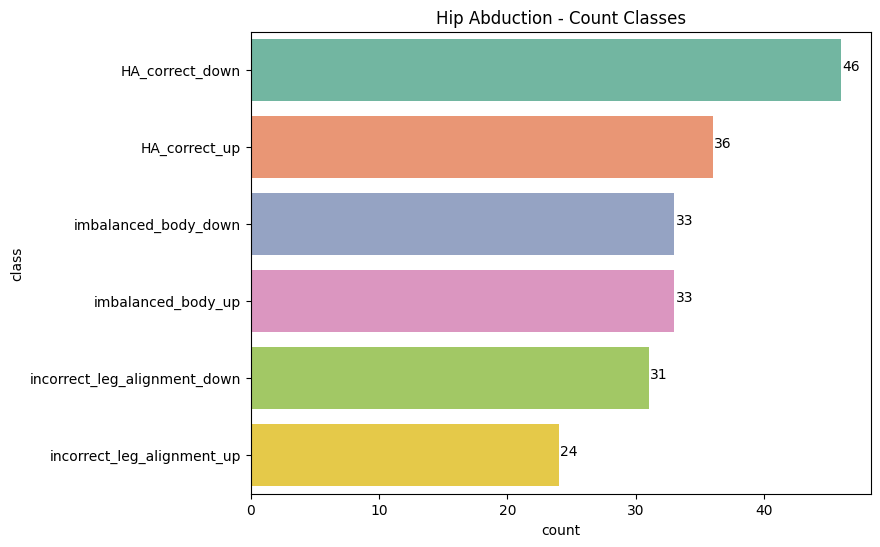

counts: 203


In [60]:
plt.figure(figsize=(8, 6))
plt.title('Hip Abduction - Count Classes')

ax = sns.countplot(y=hip_abduction['class'], palette='Set2')

for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_x() + p.get_width() + 0.1, p.get_y() + 0.4))

plt.show()
print(f'counts: {len(hip_abduction["class"])}')